## FFT-Details: Zweiseitiges Spektrum mit `np.fft`

→ Vorhergehendes Notebook: [Signal mit Rauschen](04_Signal_mit_Rauschen.ipynb)  
→ Nächstes Notebook: [FFT mit Fensterfunktion](06_fft_windowing.ipynb)

Dieses Notebook erklärt **Schritt für Schritt**, wie ein zweiseitiges Spektrum mit `numpy.fft` berechnet wird. Im Mittelpunkt stehen:

- Erzeugung eines **komplexen Zeitsignals** aus I (Realteil) und Q (Imaginärteil)
- Die **DFT/FFT** und die Bedeutung der Bin-Indizes
- Der **Frequenzvektor** aus Abtastrate und FFT-Länge
- **Betragsspektrum** und **fftshift** (negative Frequenzen in die Mitte)
- **Logarithmische Darstellung** (dB)

**Diskrete Fourier-Transformation (DFT):**

$$X[k] = \sum_{n=0}^{N-1} x[n] \, e^{-j\frac{2\pi}{N}kn} \quad \text{mit } k = 0, \ldots, N-1$$

Die **Inverse** rekonstruiert das Zeitsignal:

$$x[n] = \frac{1}{N} \sum_{k=0}^{N-1} X[k] \, e^{j\frac{2\pi}{N}kn}$$

### Parameter (von dir einstellbar)

- **Signalamplitude** für I und Q (bei Cosinus/Sinus)
- **Signalfrequenz** $f$ in Hz
- **Abtastrate** $f_s$ in Hz
- **FFT-Länge** $N$ (Anzahl Samples)
- **Signalform**: `'cos'` (Cosinus/Sinus) oder `'square'` (Rechteck)

In [36]:
import numpy as np
from matplotlib import pyplot as plt
plt.style.use('ggplot')

# === Hier einstellen ===
A_I = 5.0          # Amplitude Realteil (I)
A_Q = 1.0          # Amplitude Imaginärteil (Q)
f_signal = 100.0   # Signalfrequenz in Hz
fs = 1000.0        # Abtastrate in Hz
N = 128*2          # FFT-Länge (Anzahl Samples)
signal_type = 'square'  # 'cos' oder 'square'

# Abgeleitete Größen
T = N / fs         # Dauer des Ausschnitts in s
t = np.arange(N) / fs   # Zeitvektor

### 1. Zeitsignal: I und Q mit Zeitvektor $t$

Das **komplexe Basisband-Signal** setzt sich aus zwei reellen Signalen zusammen:

- **I** (Inphase) = Realteil
- **Q** (Quadratur) = Imaginärteil

**Option A – Cosinus/Sinus:**  
$I(t) = A_I \cos(2\pi f t)$, $\quad Q(t) = A_Q \sin(2\pi f t)$  
→ komplex: $s(t) = I(t) + j\,Q(t) = A_I\cos(\omega t) + j\,A_Q\sin(\omega t)$

**Option B – Rechteck:** I und Q sind Rechtecksignale (z. B. ±1) mit derselben Frequenz $f$.

Der **Zeitvektor** entsteht aus Abtastrate $f_s$ und Anzahl Samples $N$:

$$t[n] = \frac{n}{f_s} \quad \text{für } n = 0, 1, \ldots, N-1$$

In [28]:
# Beide Signalformen erzeugen (später wählen wir eine aus)

# Option Cosinus/Sinus
omega = 2 * np.pi * f_signal
I_cos = A_I * np.cos(omega * t)
Q_cos = A_Q * np.sin(omega * t)

# Option Rechteck (mit gleicher Grundfrequenz, I und Q 90° versetzt)
samples_per_period = max(1, int(fs / f_signal))
one_period = np.concatenate([np.ones(samples_per_period // 2), -np.ones(samples_per_period - samples_per_period // 2)])
I_square = np.tile(one_period, (N // len(one_period)) + 1)[:N] * A_I
q_period = np.roll(one_period, samples_per_period // 4)
Q_square = np.tile(q_period, (N // len(q_period)) + 1)[:N] * A_Q

# Auswahl
if signal_type == 'cos':
    I, Q = I_cos, Q_cos
else:
    I, Q = I_square, Q_square

# Komplexes Signal
samples = I + 1j * Q

### Komplexes Signal explizit darstellen

Unten: Realteil (I) und Imaginärteil (Q) über der Zeit $t$. Das komplexe Signal ist $s(t) = I(t) + j\,Q(t)$.

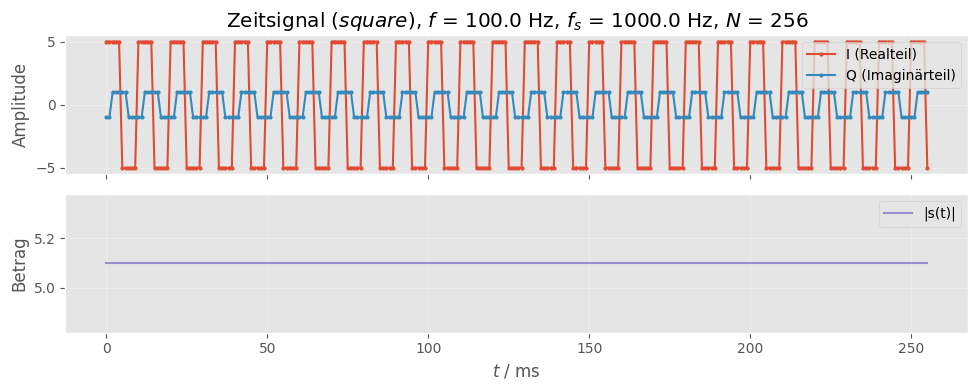

In [29]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 4), sharex=True)
ax1.plot(t * 1e3, np.real(samples), 'C0.-', label='I (Realteil)', markersize=4)
ax1.plot(t * 1e3, np.imag(samples), 'C1.-', label='Q (Imaginärteil)', markersize=4)
ax1.set_ylabel('Amplitude')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)
ax1.set_title(f'Zeitsignal (${signal_type}$), $f$ = {f_signal} Hz, $f_s$ = {fs} Hz, $N$ = {N}')
ax2.plot(t * 1e3, np.abs(samples), 'C2', label='|s(t)|')
ax2.set_xlabel('$t$ / ms')
ax2.set_ylabel('Betrag')
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 2. FFT: Unmittelbares Ergebnis (Rohspektrum)

`np.fft.fft(samples)` liefert die **komplexe Spektralfunktion** $X[k]$ für $k = 0, \ldots, N-1$.

- **Bin 0 … N/2−1:** entspricht Frequenzen $0$ bis (fast) $f_s/2$ (positive Frequenzen).
- **Bin N/2 … N−1:** entspricht **negativen Frequenzen** von $-f_s/2$ bis (fast) $0$.

In der **Rohausgabe** der FFT liegen die "negativen Frequenzen" also **oberhalb** von Bin $N/2$ – noch **ohne** Frequenzachse, nur mit Bin-Index $k$. Unten: Realteil und Imaginärteil von $X[k]$ über dem Bin-Index.

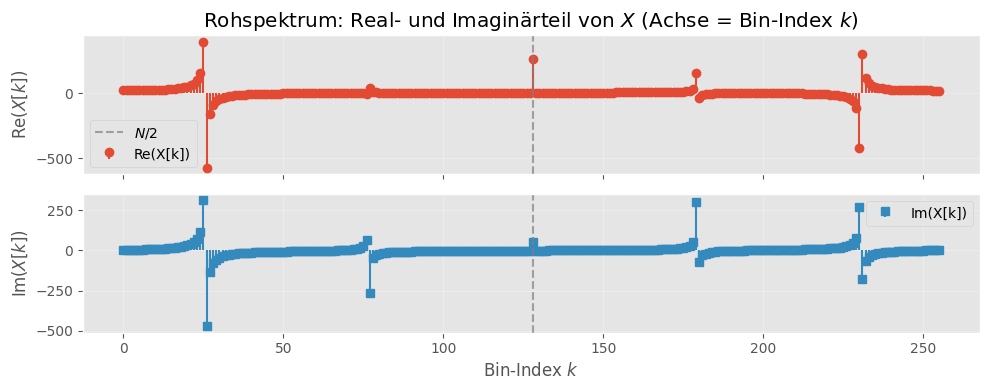

In [30]:
X = np.fft.fft(samples)
bins = np.arange(N)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 4), sharex=True)
ax1.stem(bins, np.real(X), basefmt=' ', linefmt='C0', markerfmt='C0o', label='Re(X[k])')
ax1.axvline(N // 2, color='gray', linestyle='--', alpha=0.7, label='$N/2$')
ax1.set_ylabel('Re($X[k]$)')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_title('Rohspektrum: Real- und Imaginärteil von $X$ (Achse = Bin-Index $k$)')
ax2.stem(bins, np.imag(X), basefmt=' ', linefmt='C1', markerfmt='C1s', label='Im(X[k])')
ax2.axvline(N // 2, color='gray', linestyle='--', alpha=0.7)
ax2.set_xlabel('Bin-Index $k$')
ax2.set_ylabel('Im($X[k]$)')
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 3. Frequenzvektor: `np.fft.fftfreq(N, 1/fs)`

Die Zuordnung **Bin-Index $k$ → Frequenz $f$** liefert:

$$\text{freq}[k] = \frac{k}{N\,T_s} - \frac{f_s}{2} \quad \text{bzw.} \quad \frac{k}{N} f_s \quad \text{für } 0 \leq k < N/2 \text{ und negative Frequenzen für } k \geq N/2$$

Mit **Abtastperiode** $T_s = 1/f_s$ und **FFT-Länge** $N$:

- **Frequenzauflösung:** $\Delta f = f_s / N$
- **Frequenzbereich** (vor fftshift): $0, \Delta f, 2\Delta f, \ldots, f_s/2 - \Delta f$, dann $-f_s/2, \ldots, -\Delta f$

`np.fft.fftfreq(N, 1/fs)` gibt genau diesen Vektor in **derselben Reihenfolge** wie die FFT-Ausgabe zurück (zuerst 0 … $f_s/2-\Delta f$, dann negative Frequenzen).

In [31]:
freq = np.fft.fftfreq(N, 1 / fs)
delta_f = fs / N
print(f'Frequenzauflösung Δf = fs/N = {delta_f:.2f} Hz')
print(f'freq[0] = {freq[0]:.2f} Hz, freq[1] = {freq[1]:.2f} Hz, freq[N/2] = {freq[N//2]:.2f} Hz')

Frequenzauflösung Δf = fs/N = 3.91 Hz
freq[0] = 0.00 Hz, freq[1] = 3.91 Hz, freq[N/2] = -500.00 Hz


### 4. Betragsspektrum (noch ohne fftshift)

**Magnitude:** $|X[k]| = \sqrt{\text{Re}(X[k])^2 + \text{Im}(X[k])^2}$ → `magnitude = np.abs(X)`.

Unten: Betragsspektrum über dem **Bin-Index** (noch in FFT-Reihenfolge: zuerst positive, dann negative Frequenzen).

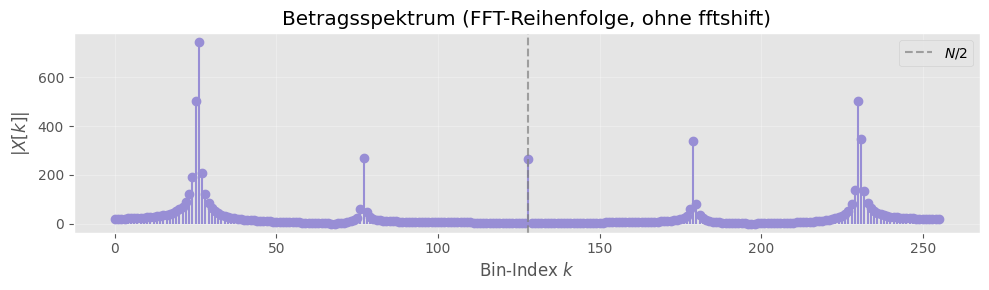

In [32]:
magnitude = np.abs(X)

fig, ax = plt.subplots(figsize=(10, 3))
ax.stem(bins, magnitude, basefmt=' ', linefmt='C2', markerfmt='C2o')
ax.axvline(N // 2, color='gray', linestyle='--', alpha=0.7, label='$N/2$')
ax.set_xlabel('Bin-Index $k$')
ax.set_ylabel('|$X[k]$|')
ax.set_title('Betragsspektrum (FFT-Reihenfolge, ohne fftshift)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5. fftshift: Negative Frequenzen in die Mitte

**Zweck:** Die FFT liefert zuerst $0 \ldots f_s/2-\Delta f$, dann $-f_s/2 \ldots -\Delta f$. Für eine **symmetrische** Darstellung um $f=0$ verschiebt man die zweite Hälfte nach vorne:

- `freq_shifted = np.fft.fftshift(freq)`
- `magnitude_shifted = np.fft.fftshift(magnitude)`

Danach läuft die Frequenzachse von $-f_s/2$ bis (fast) $+f_s/2$. So erhält man das **zweiseitige Betragsspektrum** mit Frequenzbezug.

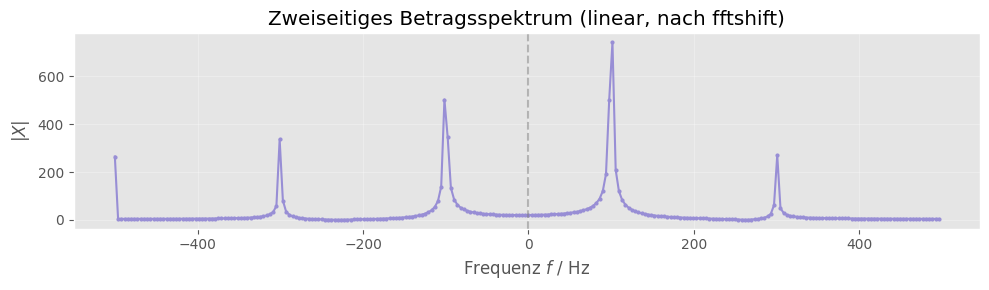

In [33]:
freq_shifted = np.fft.fftshift(freq)
magnitude_shifted = np.fft.fftshift(magnitude)

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(freq_shifted, magnitude_shifted, 'C2.-', markersize=4)
ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Frequenz $f$ / Hz')
ax.set_ylabel('|$X$|')
ax.set_title('Zweiseitiges Betragsspektrum (linear, nach fftshift)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 6. Logarithmische Darstellung (dB)

**Magnitude in dB:** $|X|_{\text{dB}} = 20\,\log_{10}(|X| + \varepsilon)$ mit kleinem $\varepsilon$ (z. B. $10^{-12}$), damit $\log(0)$ vermieden wird.

→ `magnitude_dB = 20 * np.log10(magnitude_shifted + 1e-12)`

So werden kleine Werte sichtbar und das Spektrum ist besser lesbar (typisch in der Nachrichtentechnik).

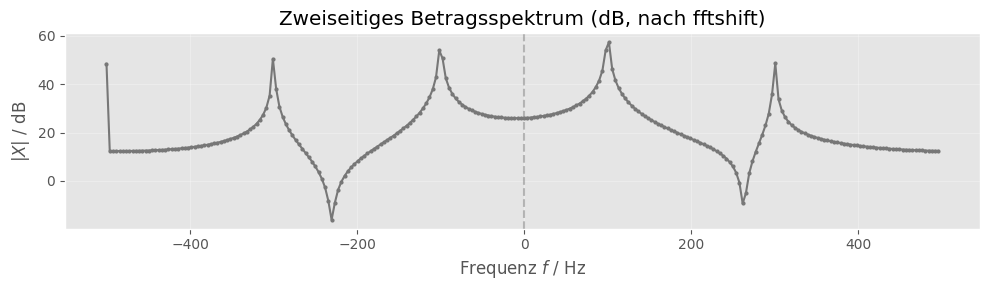

In [34]:
magnitude_dB = 20 * np.log10(magnitude_shifted + 1e-12)

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(freq_shifted, magnitude_dB, 'C3.-', markersize=4)
ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Frequenz $f$ / Hz')
ax.set_ylabel('|$X$| / dB')
ax.set_title('Zweiseitiges Betragsspektrum (dB, nach fftshift)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Zusammenfassung: Abtastrate, FFT-Länge, Frequenzbereich, Auflösung

| Größe | Formel / Bedeutung |
|--------|---------------------|
| **Abtastrate** $f_s$ | Anzahl Samples pro Sekunde (Hz). |
| **FFT-Länge** $N$ | Anzahl der Frequenzbins; typisch Potenz von 2. |
| **Frequenzbereich** | $-f_s/2 \ldots +f_s/2$ (nach fftshift). Nach Nyquist gilt: darstellbare Frequenzen $|f| \leq f_s/2$. |
| **Frequenzauflösung** $\Delta f$ | $\Delta f = f_s / N$. Je größer $N$ (bei gleichem $f_s$), desto feiner die Auflösung. |
| **Zeitdauer** | $T = N/f_s$ – die Dauer des verwendeten Zeitsignal-Ausschnitts. |

**Merke:** Längeres Fenster ($N$ groß) → bessere Frequenzauflösung $\Delta f$. Höhere Abtastrate $f_s$ → größerer darstellbarer Frequenzbereich, bei gleichem $N$ aber gröberes $\Delta f$.

*(Fensterfunktionen zur Unterdrückung von Spektral-Leakage werden hier nicht verwendet.)*

→ Vorhergehendes Notebook: [Signal mit Rauschen](04_Signal_mit_Rauschen.ipynb)
→ Nächstes Notebook: [FFT mit Fensterfunktion](06_fft_windowing.ipynb)